# PM2.5 légszennyezés előrejelzése Győr városában - EDA

# 1. Bevezetés

Ebben a notebookban a PM2.5 légszennyezettségi adatok feltáró elemzését végezzük el, több győri mérőállomás idősorán. A cél az adatok minőségének vizsgálata, tisztítása.

Két adatforrást használunk:

1. légszennyezési mérések (pollution)
2. időjárási adatok (weather)

# 2. Az adatkészlet vizsgálata, tisztítása

## Importok

A szükséges könyvtárak betöltése:

1. pandas, numpy: adatkezelés
2. matplotlib, seaborn: vizualizáció

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Adatok betöltése összeállítása

Két adatforrás: pollution és időjárás az időértékek ellenőrzése, majd egységesítése.

A pollution és weather adatokat betöltjük, majd egységes datetime formátumra hozzuk (UTC).

A két adatforrást a datetime alapján összekapcsoljuk, így minden mérési időponthoz hozzá tudjuk rendelni az időjárási jellemzőket.

(Mivel nem áll rendelkezésre állomásonként külön időjárási adat, feltételezzük, hogy a meteorológiai változók minden állomásra azonosak, ami torzítást okozhat a modellekben.)

In [2]:
pollution = pd.read_csv("../data/raw/pollutants.csv", parse_dates=["datetime"])
weather = pd.read_csv("../data/raw/weather.csv")

print("Előtte:")
print("pollution:", pollution["datetime"].dtype)
print("weather:", weather["datetime"].dtype)

weather["datetime"] = pd.to_datetime(weather["datetime"], utc=True)
pollution["datetime"] = pd.to_datetime(pollution["datetime"], utc=True)

weather = weather.drop_duplicates("datetime")

df = pollution.merge(weather, on="datetime", how="left")

df = df.sort_values("datetime")

print("Utána:")
print("pollution:", pollution["datetime"].dtype)
print("weather:", weather["datetime"].dtype)

df.head()

Előtte:
pollution: datetime64[us, UTC]
weather: str
Utána:
pollution: datetime64[us, UTC]
weather: datetime64[us, UTC]


,datetime,location,latitude,longitude,co,no2,o3,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation
0,2024-03-01 20:00:00+00:00,"""Gyor Ifjusag""",47.676111,17.649736,NaN,7.794438,NaN,37.121245,18.971765,23.500680,8.9,92,8.4,0.0
1,2024-03-01 20:00:00+00:00,"""Gyor Szent Istvan""",47.685278,17.639444,NaN,44.085993,NaN,46.815632,35.886083,5.174584,8.9,92,8.4,0.0
2,2024-03-01 20:00:00+00:00,Győr 2 Ifjúság,47.677170,17.657820,666.0,7.800000,NaN,37.000000,19.000000,23.500000,8.9,92,8.4,0.0
3,2024-03-01 21:00:00+00:00,"""Gyor Ifjusag""",47.676111,17.649736,NaN,13.354225,NaN,46.249330,22.212790,23.065620,8.1,93,7.3,0.0
4,2024-03-01 21:00:00+00:00,"""Gyor Szent Istvan""",47.685278,17.639444,NaN,38.707163,NaN,44.891465,34.419227,4.859966,8.1,93,7.3,0.0


## Állomásnevek tisztítása

Idézőjelek eltávolítása, ékezetek normalizálása, whitespace-ek törlése.

Ez biztosítja, hogy a groupby műveletek valóban azonos állomásokat kezeljenek egyként.

In [3]:
print("Előtte:")
for loc in df["location"].unique():
    print(loc)

df["location"] = (
    df["location"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.strip()
)
print("Utána:")
for loc in df["location"].unique():
    print(loc)

Előtte:
"Gyor Ifjusag"
"Gyor Szent Istvan"
Győr 2 Ifjúság
VS
Utána:
Gyor Ifjusag
Gyor Szent Istvan
Gyor 2 Ifjusag
VS


## Hiányzó adatok elemzése

A hiányzó értékek arányának vizsgálata:

1. oszloponként százalékos hiány
2. vizuális ellenőrzés heatmap segítségével

Ez segít eldönteni, mely változókat érdemes megtartani és hol szükséges imputáció.

In [4]:
#Hiányzó értékek %-ban
df.isna().mean().sort_values(ascending=False)*100

co               74.968661
o3               53.696231
no2              33.081480
so2              27.504078
pm10             17.786554
pm25             10.565811
latitude          0.000000
longitude         0.000000
datetime          0.000000
location          0.000000
temperature       0.000000
humidity          0.000000
wind_speed        0.000000
precipitation     0.000000
dtype: float64

In [5]:
#Állomásonként hiányzó értékek %-ban
missing_per_col_station = (
    df.groupby("location")
      .apply(lambda x: x.isna().mean() * 100)
      .round(1)
      .loc[:, lambda x: (x != 0).any()]
)

print(missing_per_col_station)

                      co    no2     o3  pm10  pm25    so2
location                                                 
Gyor 2 Ifjusag       3.6   21.5   10.2   7.9  40.5    0.3
Gyor Ifjusag       100.0    0.4    1.7   0.0   0.2    0.2
Gyor Szent Istvan  100.0    0.3  100.0   0.0   0.0    0.1
VS                 100.0  100.0  100.0  57.5   0.0  100.0


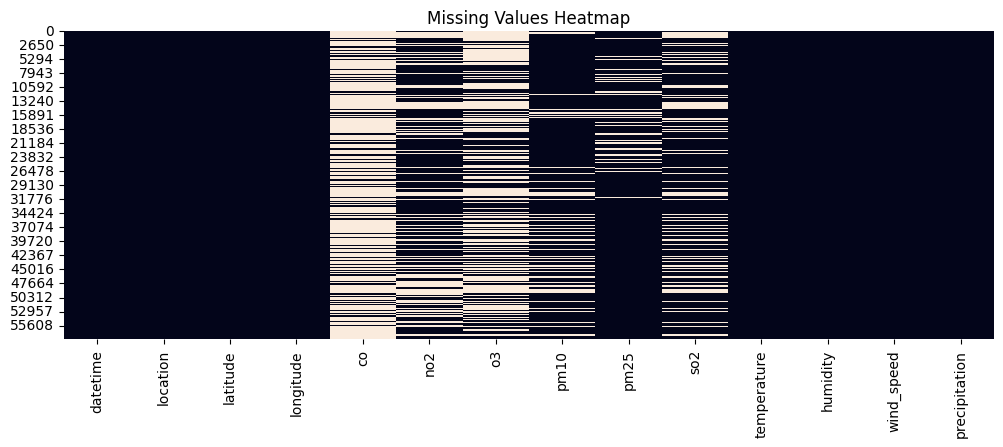

In [6]:
# Missing values heatmap
plt.figure(figsize=(12,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

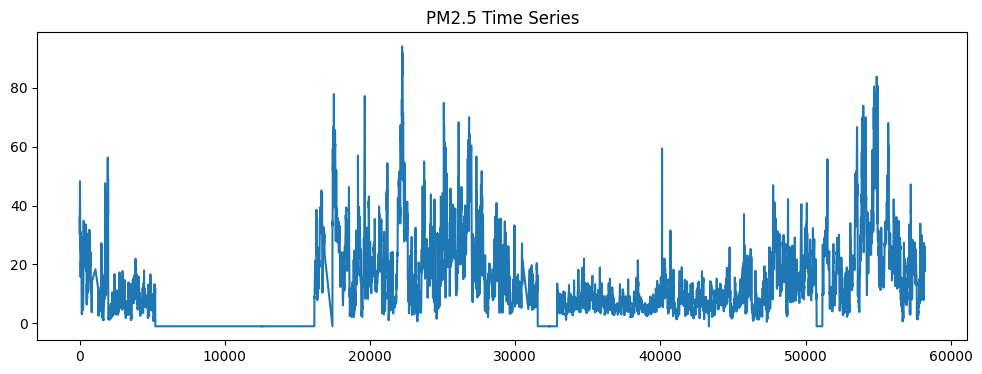

In [7]:
plt.figure(figsize=(12,4))
plt.plot(
    df[df["location"]=="Gyor Szent Istvan"]["pm25"]
)
plt.title("PM2.5 Time Series")
plt.show()

## Nagyon hiányos változók eltávolítása

Azok a változók, amelyek túl sok hiányzó értéket tartalmaznak (co, o3), eltávolításra kerülnek.

Ez csökkenti a zajt.

In [8]:
df = df.drop(columns=["co", "o3"])
df.head()

,datetime,location,latitude,longitude,no2,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation
0,2024-03-01 20:00:00+00:00,Gyor Ifjusag,47.676111,17.649736,7.794438,37.121245,18.971765,23.500680,8.9,92,8.4,0.0
1,2024-03-01 20:00:00+00:00,Gyor Szent Istvan,47.685278,17.639444,44.085993,46.815632,35.886083,5.174584,8.9,92,8.4,0.0
2,2024-03-01 20:00:00+00:00,Gyor 2 Ifjusag,47.677170,17.657820,7.800000,37.000000,19.000000,23.500000,8.9,92,8.4,0.0
3,2024-03-01 21:00:00+00:00,Gyor Ifjusag,47.676111,17.649736,13.354225,46.249330,22.212790,23.065620,8.1,93,7.3,0.0
4,2024-03-01 21:00:00+00:00,Gyor Szent Istvan,47.685278,17.639444,38.707163,44.891465,34.419227,4.859966,8.1,93,7.3,0.0


## Negatív értékek vizsgálata

Ha nincs mérés akkor az -1-el van jelölve. A légszennyezési változók nem vehetnek fel negatív értéket, ezért a negatív értékeket NaN-ra cseréljük.

In [9]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negatív érték")


no2: 2999 negatív érték
pm10: 3671 negatív érték
pm25: 8359 negatív érték
so2: 751 negatív érték
temperature: 4721 negatív érték


## A negatív értékeket NaN-al helyettesítjük

Kivéve a hőmérséklet, mert az lehet negatív.

In [10]:
pollution_cols = ["no2", "pm10", "pm25", "so2"]

for col in pollution_cols:
    df.loc[df[col] < 0, col] = np.nan
df.describe()


,latitude,longitude,no2,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation
count,58235.000000,58235.000000,35971.000000,44206.000000,43723.000000,41467.000000,58235.000000,58235.000000,58235.000000,58235.000000
mean,47.703237,17.651607,15.849164,22.708124,17.976973,6.470653,12.029673,72.416399,11.045990,0.058082
std,0.038958,0.007440,11.559250,18.509646,16.051008,8.276499,9.109682,17.980791,5.982812,0.339796
min,47.676111,17.639444,0.000000,0.000000,0.000000,0.000000,-10.500000,16.000000,0.000000,0.000000
25%,47.677170,17.649736,7.642576,11.000000,6.965312,1.700000,4.100000,60.000000,6.600000,0.000000
50%,47.685278,17.657667,12.732865,18.000000,12.904491,3.376083,11.800000,75.000000,10.300000,0.000000
75%,47.766488,17.657820,20.600000,28.525621,23.666667,5.100000,19.100000,88.000000,14.500000,0.000000
max,47.766488,17.657820,140.571869,444.000000,395.000000,235.300000,36.000000,100.000000,43.500000,18.800000


## Állomások közti időkülönbségek

Megvizsgáljuk az egyes állomások mérési időközeit, hogy vannak-e hiányzó időpontok, egyenletes-e a mintavételezés.

Ez alapvető feltétele az idősoros modellezésnek.

In [11]:
df_time_diff = df.sort_values(["location", "datetime"])

time_diff = df.groupby("location")["datetime"].diff()
time_diff.value_counts().head(10)

datetime
0 days 01:00:00    56904
0 days 02:00:00      604
0 days 03:00:00      183
0 days 04:00:00      141
0 days 05:00:00       78
0 days 06:00:00       66
0 days 07:00:00       41
0 days 09:00:00       32
0 days 08:00:00       31
1 days 00:00:00       19
Name: count, dtype: int64

Az eredményből az látszik, hogy hiányoznak órák, van ahol napok is.

## Duplikált időbélyegek keresése
Ellenőrizzük, hogy van-e azonos időpont ugyanarra az állomásra többször.

Duplikáció esetén torzulhat az átlagolás, hibás lesz a resampling.

In [12]:
df.duplicated(subset=["datetime", "location"]).sum()


np.int64(0)

## Időstruktúra létrehozása - óránként és állomásonként
Duplikált adatok nincsenek, de hiányzó órák vannak, amit az alábbi módszerrel kezelünk. Külön idősor állomásonként és a hiányzóakat Nan-al töltjük fel.

Az adatokat órás frekvenciára alakítjuk állomásonként:

1. hiányzó időpontok létrejönnek (NaN)
2. több mérés esetén átlagolás történik

Ez egységes idősorokat biztosít, ami szükséges a modellezéshez.

In [13]:
pollutant_cols = ["no2", "pm10", "pm25", "so2"]
weather_cols   = ["temperature", "humidity", "wind_speed", "precipitation"]
coord_cols     = ["latitude", "longitude"]

df_original = df.copy()

# --- pollutáns ---
df_poll = (
    df_original[["location", "datetime"] + pollutant_cols]
    .set_index(["location", "datetime"])
    .groupby(level="location")
    .resample("1h", level="datetime")
    .mean()
    .reset_index()
)

# --- weather ---
df_weather = (
    df_original[["datetime"] + weather_cols]
    .drop_duplicates("datetime")
    .set_index("datetime")
    .resample("1h")
    .mean()
    .reset_index()
)

# --- merge ---
df = df_poll.merge(df_weather, on="datetime", how="left")

# --- coords (eredetiből!) ---
coords = df_original[["location"] + coord_cols].drop_duplicates()

df = df.merge(coords, on="location", how="left")


## Interpolate per station
A hiányzó értékeket állomásonként interpoláljuk:

1. lineáris interpoláció a szomszédos értékek alapján.
2. forward fill az elején

Ez biztosítja a folytonos idősorokat.

Megjegyzés: Csúcsok elvesztését okozhatja. Későbbi vizsgálat szükséges.

In [14]:

# --- WEATHER interpoláció (globális, nem location szerint) ---
weather_cols = ["temperature", "humidity", "wind_speed", "precipitation"]

df = df.sort_values("datetime")

df[weather_cols] = (
    df[weather_cols]
    .interpolate(limit=3, limit_direction="forward")
)

# --- POLLUTÁNS interpoláció ---
df = df.sort_values(["location", "datetime"])
cols_to_interp = ["pm25", "pm10", "no2", "so2"]

df[cols_to_interp] = (
    df.groupby("location")[cols_to_interp]
      .apply(lambda x: x.interpolate(limit=3, limit_direction="forward"))
      .reset_index(level=0, drop=True)
)


df.head()


,location,datetime,no2,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation,latitude,longitude
0,Gyor 2 Ifjusag,2024-03-01 20:00:00+00:00,7.8,37.0,19.0,23.5,8.9,92.0,8.4,0.0,47.67717,17.65782
1,Gyor 2 Ifjusag,2024-03-01 21:00:00+00:00,13.4,46.0,22.0,23.1,8.1,93.0,7.3,0.0,47.67717,17.65782
2,Gyor 2 Ifjusag,2024-03-01 22:00:00+00:00,12.4,48.0,19.0,23.3,7.3,95.0,7.0,0.0,47.67717,17.65782
3,Gyor 2 Ifjusag,2024-03-01 23:00:00+00:00,10.2,40.0,15.0,23.3,6.1,97.0,10.3,0.0,47.67717,17.65782
4,Gyor 2 Ifjusag,2024-03-02 00:00:00+00:00,8.1,38.0,19.0,22.6,5.4,99.0,9.2,0.0,47.67717,17.65782


Konzisztencia-ellenőrzés, ami azt vizsgálja, hogy minden állomásnál az időlépések pontosan 1 órásak-e.

In [15]:
df_time_diff = df.sort_values(["location", "datetime"])

time_diff = df.groupby("location")["datetime"].diff()
time_diff.value_counts().head(10)

datetime
0 days 01:00:00    70073
Name: count, dtype: int64

In [16]:
assert df.groupby("location")["datetime"].diff().dropna().eq(pd.Timedelta("1h")).all()

Nincs hiba tehát:

1. teljesen folytonos
2. nincs kihagyott időpont
3. nincs duplikáció

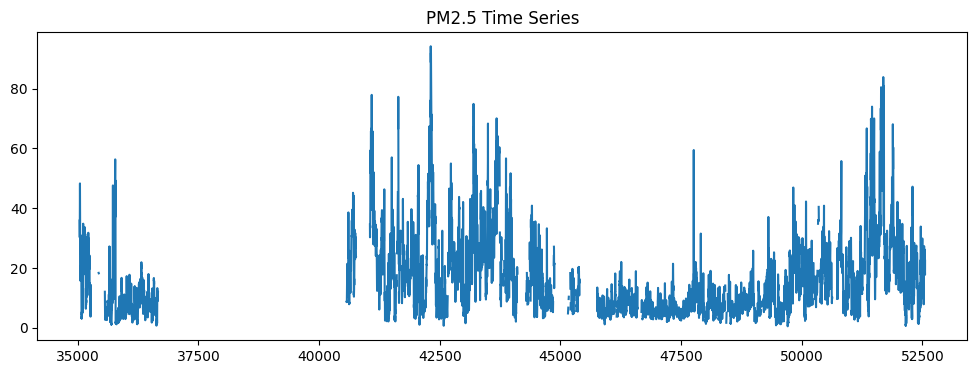

In [17]:
plt.figure(figsize=(12,4))
plt.plot(
    df[df["location"]=="Gyor Szent Istvan"]["pm25"]
)
plt.title("PM2.5 Time Series")
plt.show()

## Eloszlás

A PM2.5 eloszlását vizsgáljuk:

1. hisztogram
2. KDE görbe

Ez segít megérteni a ferdeséget, szélső értékeket, transzformáció szükségességét.

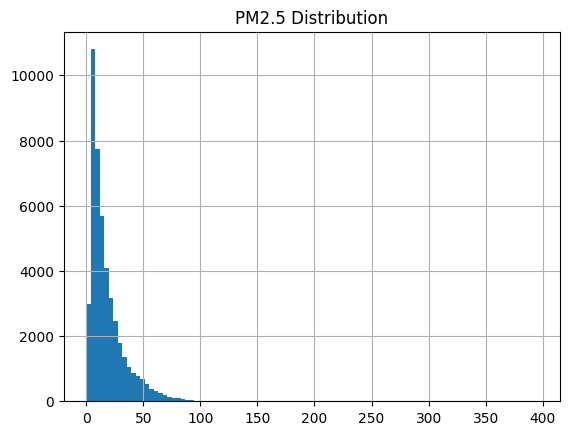

In [18]:
df["pm25"].hist(bins=100)
plt.title("PM2.5 Distribution")
plt.show()

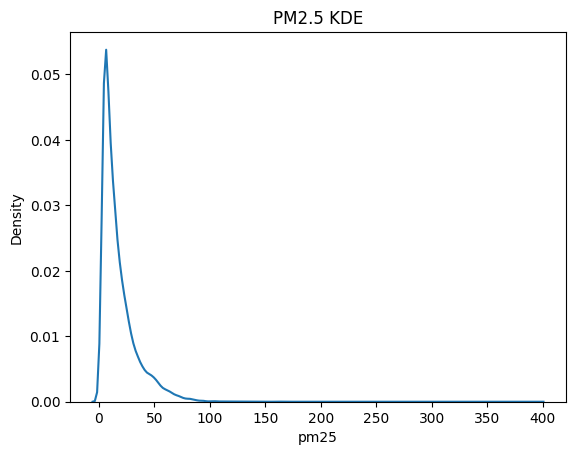

In [19]:
sns.kdeplot(df["pm25"].dropna())
plt.title("PM2.5 KDE")
plt.show()

## Szélső értékek - outliers
Z-score alapú módszerrel azonosítjuk a szélső értékeket állomásonként.

Ez segít:

- extrém események felismerésében
- adatminőség ellenőrzésében

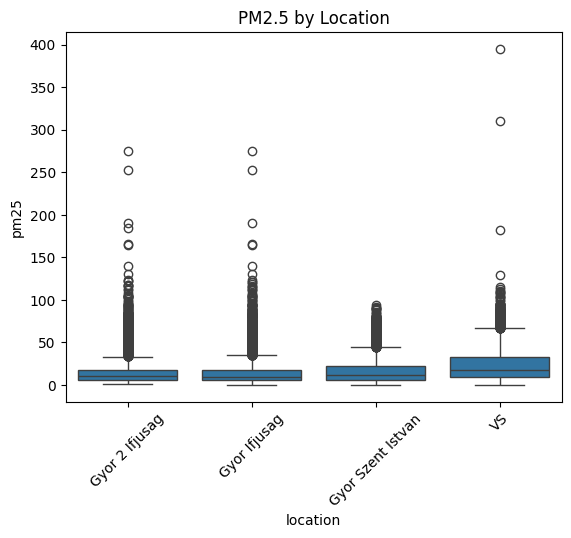

In [20]:
sns.boxplot(data=df, x="location", y="pm25")
plt.xticks(rotation=45)
plt.title("PM2.5 by Location")
plt.show()


In [21]:
z = df.groupby("location")["pm25"].transform(
    lambda x: (x - x.mean()) / x.std()
)
outliers = df[np.abs(z) > 5]

outliers.head()

,location,datetime,no2,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation,latitude,longitude
8688,Gyor 2 Ifjusag,2025-02-26 20:00:00+00:00,25.3,86.0,93.000000,2.9,5.4,95.0,6.2,0.3,47.67717,17.65782
8707,Gyor 2 Ifjusag,2025-02-27 15:00:00+00:00,32.6,46.0,123.000000,2.4,5.5,96.0,10.5,1.7,47.67717,17.65782
9535,Gyor 2 Ifjusag,2025-04-03 03:00:00+00:00,14.5,28.0,105.666667,1.7,7.8,79.0,8.3,0.0,47.67717,17.65782
9536,Gyor 2 Ifjusag,2025-04-03 04:00:00+00:00,27.5,28.0,190.333333,1.9,6.6,82.0,8.2,0.0,47.67717,17.65782
9537,Gyor 2 Ifjusag,2025-04-03 05:00:00+00:00,36.3,29.0,275.000000,2.0,6.2,83.0,8.1,0.0,47.67717,17.65782


Két módszert választhatunk az outlierek kezelésére:
1. Levágjuk őket felső limit beállításával - df["pm25"] = df["pm25"].clip(upper=300)
2. Vagy logaritmikus transzformációt alkalmazunk train-nél - df["pm25_log"] = np.log1p(df["pm25"])

Utóbbit választjuk, mert a magas értékek lehetnek valós csúcsok is.

A logaritmikus transzformáció:

- csökkenti a ferdeséget
- stabilizálja a varianciát
- gyakran javítja a modellek teljesítményét

In [22]:
#Állomásonként hiányzó értékek %-ban - utolsó ellenőrzés
missing_per_col_station = (
    df.groupby("location")
      .apply(lambda x: x.isna().mean() * 100)
      .round(1)
      .loc[:, lambda x: (x != 0).any()]
)

print(missing_per_col_station)

                     no2  pm10  pm25    so2  temperature  humidity  \
location                                                             
Gyor 2 Ifjusag      29.5  17.7  46.3   11.1          0.3       0.3   
Gyor Ifjusag        34.5  23.5  51.3   17.1          0.3       0.3   
Gyor Szent Istvan   17.9  34.7  34.7   21.7          0.3       0.3   
VS                 100.0  59.9   7.0  100.0          0.3       0.3   

                   wind_speed  precipitation  
location                                      
Gyor 2 Ifjusag            0.3            0.3  
Gyor Ifjusag              0.3            0.3  
Gyor Szent Istvan         0.3            0.3  
VS                        0.3            0.3  


In [23]:
df.to_csv("../data/preprocessed/eda_preprocessed.csv", index=False)

# 3. Eredmények

Az így előállított dataset:

1. konzisztens idősorokat tartalmaz
2. alkalmas prediktív modellek tanítására
3. csökkenti az adatminőségi problémák hatását